In [6]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import seaborn as sns

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.graph_analysis import (
    calculate_moments_error,
    calculate_annd_error,
    calculate_eccentricity_error,
    calculate_motifs_error,
)
from notebooks.visualization_utils import save_figure_pdf

In [7]:
# Exactly ONE of the three variables should be None at a time; the other two
# must be set to a single valid string from the canonical orders below.
FIXED_METHODS:  str | None = None            # set to None to vary methods (methods vary)
FIXED_SAMPLERS: str | None = "nosampler"     # chosen and fixed
FIXED_FEATURES: str | None = "log_bin_deg"   # chosen and fixed

SYNTHETIC_DATA_DIR = PROJECT_ROOT / "synthetic_data"
DATASET_NAMES = [
        "BZR", 
        "DHFR", 
        "MUTAG", 
        "Mutagenicity", 
        "COX2", 
        "ENZYMES", 
        "NCI109", 
        "AIDS", 
        "NCI1", 
        "PROTEINS"
]

# Cache original dataset statistics for target secondary metrics
original_stats_cache = {}
for dname in DATASET_NAMES:
    if FIXED_FEATURES is not None:
        orig_path = PROJECT_ROOT / "data" / dname / f"{dname}_original_{FIXED_FEATURES}.pt"
        if not orig_path.exists():
            orig_path = PROJECT_ROOT / "data" / dname / f"{dname}_original.pt"
    else:
        orig_path = PROJECT_ROOT / "data" / dname / f"{dname}_original.pt"
    if orig_path.exists():
        try:
            payload = torch.load(orig_path, map_location="cpu", weights_only=False)
            original_stats_cache[dname] = payload.get("metadata", {}).get("per_graph_statistics", [])
        except Exception as e:
            print(f"Warning: Failed to load original dataset statistics for {dname}: {e}")

# Methods
METHOD_ORDER = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "nextGen"]
METHOD_PALETTE = {
    "original":   "#5B9BD5",
    "dummyNodes": "#E07A5F",
    "dummyEdges": "#F4A261",
    "padma":      "#F2CC8F",
    "anndg":      "#8A4F7D",
    "anndgE":     "#B56576",
    # "ergm":       "#6B705C",
    "nextGen":    "#9E2A2B",
}

METHOD_LABELS = {
    "dummyNodes": "DummyNodes",
    "dummyEdges": "DummyEdges",
    "padma":      "PADMA",
    "anndg":      "DpfAnnd",
    "anndgE":     "DpfAnnd+E",
    # "ergm":       "GARME",
}

fontsize = 15
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

def _canonical_order(values, order):
    """Return values sorted by canonical order, with unknown values appended."""
    present = set(values)
    return [v for v in order if v in present] + sorted(v for v in present if v not in order)

def safe_array(val, expected_length=4):
    """Safely convert any value to a float 1D numpy array of expected length."""
    if val is None:
        return np.zeros(expected_length)
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val, dtype=float)
        if len(arr) == expected_length:
            return arr
    arr = np.atleast_1d(val).astype(float)
    if len(arr) < expected_length:
        pad = np.zeros(expected_length - len(arr))
        arr = np.concatenate([arr, pad])
    return arr[:expected_length]

def load_fidelity_data() -> pd.DataFrame:
    """Loads and aggregates target fidelity statistics from synthetic dataset metadata."""
    sampler_alts = "|".join(re.escape(s) for s in ["nosampler", "moments", "percentile", "percentile_corr", "gmcm"])
    filename_pattern = re.compile(
        r"(?P<dataset>[A-Za-z][A-Za-z0-9\-]*)_"          # dataset name
        r"(?P<method>[A-Za-z][A-Za-z0-9]*)_"             # method name
        r"(?P<sampler>" + sampler_alts + r")_"           # sampler (exact match)
        r"(?P<feature>[a-zA-Z0-9_]+)_"                   # feature strategy
        r"v(?P<variant>\d+)\.pt$"                        # variant index
    )

    rows = []
    pt_paths = list(SYNTHETIC_DATA_DIR.glob("*.pt"))
    if not pt_paths:
        raise FileNotFoundError(f"No synthetic .pt files found in {SYNTHETIC_DATA_DIR}.")

    print(f"Scanning {len(pt_paths)} files in {SYNTHETIC_DATA_DIR}...")
    
    for pt_path in pt_paths:
        match = filename_pattern.match(pt_path.name)
        if match is None:
            continue
            
        dataset = match.group("dataset")
        method = match.group("method")
        sampler = match.group("sampler")
        feature = match.group("feature")
        variant = int(match.group("variant"))

        if dataset not in DATASET_NAMES:
            continue
        if FIXED_SAMPLERS is not None and sampler != FIXED_SAMPLERS:
            continue
        if FIXED_FEATURES is not None and feature != FIXED_FEATURES:
            continue
        if FIXED_METHODS is not None and method != FIXED_METHODS:
            continue
        if method == "ergm":
            continue

        try:
            payload = torch.load(pt_path, map_location="cpu", weights_only=False)
            metadata = payload.get("metadata", {})
        except Exception as e:
            print(f"Warning: Failed to load {pt_path.name}: {e}")
            continue

        target_stats = metadata.get("per_graph_target_statistics", [])
        actual_stats = metadata.get("per_graph_statistics", [])

        if not target_stats or not actual_stats:
            continue

        n_graphs = min(len(target_stats), len(actual_stats))
        for i in range(n_graphs):
            t_stat = target_stats[i]
            a_stat = actual_stats[i]

            if t_stat is None or a_stat is None:
                continue

            # Core topological features
            t_n_nodes = t_stat.get("n_nodes")
            a_n_nodes = a_stat.get("n_nodes")
            t_n_edges = t_stat.get("n_edges")
            a_n_edges = a_stat.get("n_edges")

            # Degree moments (length 4)
            t_moments = safe_array(t_stat.get("degree_moments"))
            a_moments = safe_array(a_stat.get("degree_moments"))

            # ANND (length 4)
            t_annd = safe_array(t_stat.get("annd"))
            a_annd = safe_array(a_stat.get("annd"))

            # Eccentricity (length 4)
            t_ecc = safe_array(t_stat.get("eccentricity"))
            a_ecc = safe_array(a_stat.get("eccentricity"))

            # Motifs (length 8 for k=4)
            t_motifs = safe_array(t_stat.get("motifs"), expected_length=8)
            a_motifs = safe_array(a_stat.get("motifs"), expected_length=8)

            # Retrieve target secondary metrics from caching of original datasets
            orig_stat = {}
            if dataset in original_stats_cache and i < len(original_stats_cache[dataset]):
                orig_stat = original_stats_cache[dataset][i]

            t_clustering = orig_stat.get("clustering")
            t_assortativity = orig_stat.get("assortativity")
            t_modularity = orig_stat.get("modularity")
            t_efficiency = orig_stat.get("efficiency")

            row = {
                "dataset": dataset,
                "method": method,
                "sampler": sampler,
                "feature": feature,
                "variant": variant,
                "graph_idx": i,
                
                # Topological counts & structures (Target vs Actual)
                "target_n_nodes": t_n_nodes,
                "actual_n_nodes": a_n_nodes,
                "target_n_edges": t_n_edges,
                "actual_n_edges": a_n_edges,
                
                # Degree Moments Detail
                "target_deg_mean": t_moments[0],
                "target_deg_var": t_moments[1],
                "target_deg_skew": t_moments[2],
                "target_deg_kurt": t_moments[3],
                "actual_deg_mean": a_moments[0],
                "actual_deg_var": a_moments[1],
                "actual_deg_skew": a_moments[2],
                "actual_deg_kurt": a_moments[3],
                
                # Secondary metrics (Target vs Actual)
                "target_clustering": t_clustering,
                "actual_clustering": a_stat.get("clustering"),
                "target_assortativity": t_assortativity,
                "actual_assortativity": a_stat.get("assortativity"),
                "target_modularity": t_modularity,
                "actual_modularity": a_stat.get("modularity"),
                "target_efficiency": t_efficiency,
                "actual_efficiency": a_stat.get("efficiency"),
                "target_diameter": t_stat.get("diameter"),
                "actual_diameter": a_stat.get("diameter"),
            }

            # Detail bins for ANND and Eccentricity
            for idx in range(4):
                row[f"target_annd_{idx}"] = t_annd[idx]
                row[f"actual_annd_{idx}"] = a_annd[idx]
                row[f"target_eccentricity_{idx}"] = t_ecc[idx]
                row[f"actual_eccentricity_{idx}"] = a_ecc[idx]
                
            # Detail for Motifs
            for idx in range(8):
                row[f"target_motifs_{idx}"] = t_motifs[idx]
                row[f"actual_motifs_{idx}"] = a_motifs[idx]

            rows.append(row)

    if not rows:
        raise ValueError(f"No matching data loaded. Check settings: FIXED_SAMPLERS={FIXED_SAMPLERS}, FIXED_FEATURES={FIXED_FEATURES}")

    df_fidelity = pd.DataFrame(rows)
    
    # Set categorical orders for consistency in plotting
    all_methods = set(df_fidelity["method"].dropna())
    ordered_m = _canonical_order(all_methods, METHOD_ORDER)
    df_fidelity["method"] = pd.Categorical(df_fidelity["method"], categories=ordered_m, ordered=True)
    
    print(f"Successfully loaded {len(df_fidelity)} records representing raw fidelity statistics for {len(all_methods)} methods.")
    return df_fidelity

def compute_fidelity_errors(df: pd.DataFrame) -> pd.DataFrame:
    """Computes structural error metrics from target vs actual graph statistics."""
    error_rows = []
    
    print(f"Computing structural errors for {len(df)} records...")
    
    for idx, row in df.iterrows():
        err_row = {
            "dataset": row["dataset"],
            "method": row["method"],
            "sampler": row["sampler"],
            "feature": row["feature"],
            "variant": row["variant"],
            "graph_idx": row["graph_idx"],
        }
        
        # Absolute Errors for scalar counts
        err_row["nodes_error"] = abs(row["actual_n_nodes"] - row["target_n_nodes"])
        err_row["edges_error"] = abs(row["actual_n_edges"] - row["target_n_edges"])
        
        # Absolute Errors for secondary metrics
        for metric in ["clustering", "assortativity", "modularity", "efficiency", "diameter"]:
            t_val = row[f"target_{metric}"]
            a_val = row[f"actual_{metric}"]
            if t_val is not None and a_val is not None and not pd.isna(t_val) and not pd.isna(a_val):
                err_row[f"{metric}_error"] = abs(a_val - t_val)
            else:
                err_row[f"{metric}_error"] = np.nan
        
        # Specialized Errors for degree moments
        t_moments = np.array([
            row["target_deg_mean"],
            row["target_deg_var"],
            row["target_deg_skew"],
            row["target_deg_kurt"]
        ])
        a_moments = np.array([
            row["actual_deg_mean"],
            row["actual_deg_var"],
            row["actual_deg_skew"],
            row["actual_deg_kurt"]
        ])
        err_row["moments_error"] = calculate_moments_error(a_moments, t_moments)
        
        # Specialized Errors for ANND
        t_annd = np.array([row[f"target_annd_{i}"] for i in range(4)])
        a_annd = np.array([row[f"actual_annd_{i}"] for i in range(4)])
        err_row["annd_error"] = calculate_annd_error(a_annd, t_annd)
        
        # Specialized Errors for Eccentricity
        t_ecc = np.array([row[f"target_eccentricity_{i}"] for i in range(4)])
        a_ecc = np.array([row[f"actual_eccentricity_{i}"] for i in range(4)])
        err_row["eccentricity_error"] = calculate_eccentricity_error(a_ecc, t_ecc)
        
        # Specialized Errors for Motifs
        t_motifs = np.array([row[f"target_motifs_{i}"] for i in range(8)])
        a_motifs = np.array([row[f"actual_motifs_{i}"] for i in range(8)])
        err_row["motifs_error"] = calculate_motifs_error(a_motifs, t_motifs)
        
        error_rows.append(err_row)
        
    df_errors = pd.DataFrame(error_rows)
    
    # Ensure canonical ordering on methods
    if "method" in df_errors.columns:
        df_errors["method"] = pd.Categorical(df_errors["method"], categories=df["method"].cat.categories, ordered=True)
        
    print(f"Successfully computed errors. Created error DataFrame with shape {df_errors.shape}.")
    return df_errors

df_fidelity = load_fidelity_data()
df_errors = compute_fidelity_errors(df_fidelity)

# Derived globals (similar to gnn_result_analysis.py)
METHODS = sorted(df_fidelity["method"].dropna().unique().tolist())
DATASETS = sorted(df_fidelity["dataset"].dropna().unique().tolist())

Scanning 2160 files in /home/amarigo/syn_bench_gnn2/syn_bench_gnn/synthetic_data...
Successfully loaded 455600 records representing raw fidelity statistics for 5 methods.
Computing structural errors for 455600 records...
Successfully computed errors. Created error DataFrame with shape (455600, 17).


/tmp/ipykernel_1336503/1780080350.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = sub_df.groupby("method")[error_metrics].mean().T
/tmp/ipykernel_1336503/1780080350.py:80: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = summary_df.applymap(format_annotation)
/tmp/ipykernel_1336503/1780080350.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[save_figure_pdf] Saved → /home/amarigo/syn_bench_gnn2/syn_bench_gnn/target_fidelity_heatmap.pdf


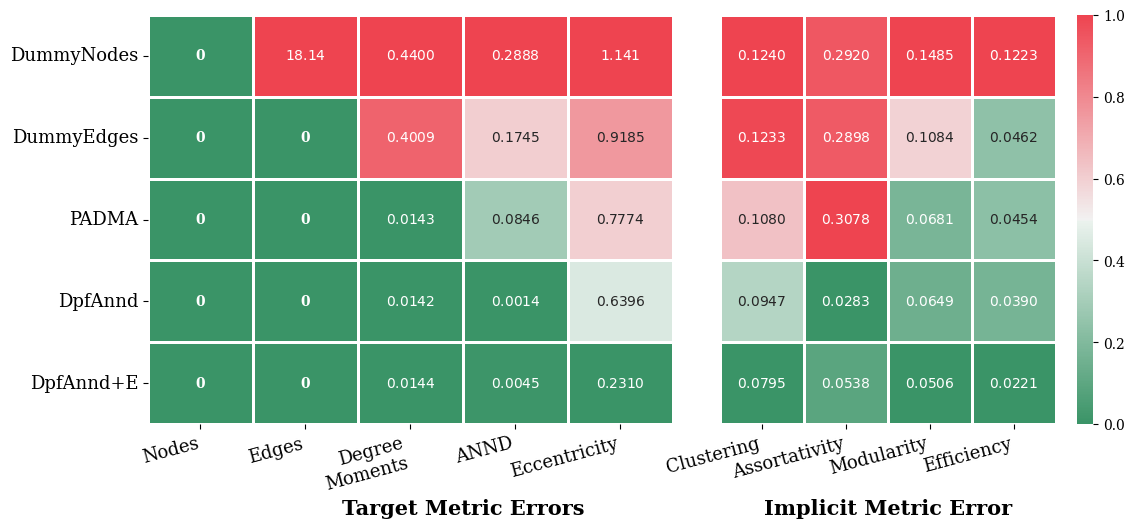

In [8]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

def plot_executive_error_heatmap(
    df_errors: pd.DataFrame,
    error_metrics: list[str],
    dataset_name: str | None = None,
    methods_on_x: bool = True,
):
    """5. Executive Summary Heatmap showing mean structural error.
    
    Rows are structural statistics, columns are generators (default).
    Set methods_on_x=False to swap: methods on y-axis, metrics on x-axis.
    Cells show the raw Mean Absolute Error (MAE), color-coded by relative performance
    using a green (low error/best) -> yellow (medium) -> red (high error/worst) gradient.
    Very small errors are formatted in scientific notation for high precision.
    
    Parameters
    ----------
    df_errors : pd.DataFrame
        DataFrame with pre-computed error metrics.
    error_metrics : list[str]
        List of column names (error metrics) to include in the heatmap.
    dataset_name : str | None
        If provided, filter to this dataset only.
    methods_on_x : bool
        If True (default), methods appear on the x-axis (columns) and metrics on the
        y-axis (rows). If False, methods appear on the y-axis (rows) and metrics on
        the x-axis (columns).
    """
    if dataset_name is not None:
        sub_df = df_errors[df_errors["dataset"] == dataset_name]
    else:
        sub_df = df_errors
        
    # Compute Mean Absolute Error for each method
    # summary_df: index=metrics, columns=methods
    summary_df = sub_df.groupby("method")[error_metrics].mean().T

    # Apply METHOD_LABELS to column names (methods)
    summary_df.columns = [METHOD_LABELS.get(m, m) for m in summary_df.columns]
    
    friendly_names = {
        "nodes_error": "Nodes",
        "edges_error": "Edges",
        "moments_error": "Degree\nMoments",
        "annd_error": "ANND",
        "eccentricity_error": "Eccentricity",
        "motifs_error": "Graphlets",
        "clustering_error": "Clustering",
        "assortativity_error": "Assortativity",
        "modularity_error": "Modularity",
        "efficiency_error": "Efficiency",
        "diameter_error": "Diameter"
    }
    summary_df.index = summary_df.index.map(friendly_names)
    
    # If methods should be on y-axis, transpose so rows=methods, cols=metrics
    gap_idx = -1
    if not methods_on_x:
        summary_df = summary_df.T
        cols = list(summary_df.columns)
        for i, col in enumerate(cols):
            if col in ["Clustering", "Assortativity", "Modularity", "Efficiency", "Diameter"]:
                gap_idx = i
                break
    
    # Custom cell formatting: LaTeX math notation for all values
    def format_annotation(val):
        if pd.isna(val):
            return ""
        if abs(val) < 1e-12:
            return "0"
        if abs(val) < 1:
            return rf"${val:.4f}$"
        if abs(val) < 10:
            return rf"${val:.3f}$"
        return rf"${val:.2f}$"
        
    annot_labels = summary_df.applymap(format_annotation)
    
    # Colormap Data — normalise metric-wise (each metric independently)
    if methods_on_x:
        # metrics are on rows, so normalise across columns (axis=1)
        metric_min = summary_df.min(axis=1).values[:, np.newaxis]
        metric_max = summary_df.max(axis=1).values[:, np.newaxis]
    else:
        # metrics are on columns, so normalise across rows (axis=0)
        metric_min = summary_df.min(axis=0).values[np.newaxis, :]
        metric_max = summary_df.max(axis=0).values[np.newaxis, :]
    color_data = (summary_df.values - metric_min) / (metric_max - metric_min + 1e-8)
    color_df = pd.DataFrame(color_data, index=summary_df.index, columns=summary_df.columns)

    n_rows, n_cols = color_df.shape
    extra_h = 1.0 if (not methods_on_x and gap_idx != -1) else 0.0
    cmap = sns.diverging_palette(145, 10, s=80, l=55, as_cmap=True)

    if not methods_on_x and gap_idx != -1:
        fig, (ax1, ax2) = plt.subplots(
            1, 2, 
            figsize=(2 + 1.2 * n_cols, 0.8 * n_rows + 1.5 + extra_h),
            gridspec_kw={'width_ratios': [gap_idx, n_cols - gap_idx], 'wspace': 0.1}
        )
        sns.heatmap(
            color_df.iloc[:, :gap_idx],
            annot=annot_labels.iloc[:, :gap_idx],
            fmt="", cmap=cmap, linewidths=0.8,
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            cbar=False, vmin=0, vmax=1, ax=ax1
        )
        sns.heatmap(
            color_df.iloc[:, gap_idx:],
            annot=annot_labels.iloc[:, gap_idx:],
            fmt="", cmap=cmap, linewidths=0.8,
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            cbar_kws={"aspect": 25}, vmin=0, vmax=1, ax=ax2
        )
        
        # ax1.set_ylabel("Generator", fontsize=15, fontweight="bold")
        ax1.set_xlabel("")
        ax2.set_ylabel("")
        ax2.set_xlabel("")
        ax2.set_yticks([])
        
        ax1.tick_params(axis='x', labelsize=13, rotation=15)
        ax1.tick_params(axis='y', labelsize=13, rotation=0)
        ax2.tick_params(axis='x', labelsize=13, rotation=15)
        
        for axes in [ax1, ax2]:
            for tick in axes.get_xticklabels():
                tick.set_horizontalalignment("right")
        
        trans1 = ax1.get_xaxis_transform()
        ax1.annotate("Target Metric Errors", xy=(3, -0.18), xycoords=trans1, 
                     ha='center', va='top', fontsize=15, fontweight='bold', annotation_clip=False)
        trans2 = ax2.get_xaxis_transform()
        ax2.annotate("Implicit Metric Error", xy=(2, -0.18), xycoords=trans2, 
                     ha='center', va='top', fontsize=15, fontweight='bold', annotation_clip=False)
        
        plt.tight_layout()
        fig.subplots_adjust(bottom=0.25, wspace=0.1)
        save_figure_pdf(fig, ax1, PROJECT_ROOT / "target_fidelity_heatmap.pdf")
    else:
        fig, ax = plt.subplots(figsize=(2 + 1.2 * n_cols, 0.8 * n_rows + 1.5))
        sns.heatmap(
            color_df, annot=annot_labels, fmt="", cmap=cmap, linewidths=0.8,
            annot_kws={"fontsize": 10, "fontweight": "bold"},
            cbar_kws={"aspect": 25}, ax=ax
        )
        if methods_on_x:
            ax.set_ylabel("Error Metric", fontsize=15, fontweight="bold")
            ax.set_xlabel("Generator", fontsize=15, fontweight="bold")
        else:
            ax.set_ylabel("Generator", fontsize=15, fontweight="bold")
            ax.set_xlabel("Error Metric", fontsize=15, fontweight="bold")
            
        ax.tick_params(axis='x', labelsize=13, rotation=15)
        ax.tick_params(axis='y', labelsize=13, rotation=0)
        plt.xticks(ha="right")
        plt.tight_layout()
        save_figure_pdf(fig, ax, PROJECT_ROOT / "target_fidelity_heatmap.pdf")
    return

plot_executive_error_heatmap(df_errors, methods_on_x=False, error_metrics=["nodes_error", "edges_error", "moments_error", "annd_error", "eccentricity_error", "clustering_error", "assortativity_error", "modularity_error", "efficiency_error"])